# 🏨 Hotel Booking Data Cleaning & Exploratory Data Analysis

## Project Objective

This project focuses on cleaning and analyzing a hotel booking dataset using Python.

### Key Tasks
- Data loading and inspection
- Handling missing values
- Removing duplicate records
- Converting data types
- Detecting and treating outliers
- Exploratory Data Analysis (EDA)
- Identifying important booking trends and patterns
- Exporting the cleaned dataset

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## 1. Data Loading

The hotel booking dataset is loaded using Pandas. The dataset contains information about hotel bookings, customer details, stay duration, booking channels, cancellations, and other booking-related attributes.

## 2. Data Overview

The dataset was inspected to understand its structure, dimensions, column names, data types, and missing values before performing data cleaning.

## 3. Data Cleaning

The dataset was cleaned by handling missing values, removing duplicate records, converting date columns to appropriate data types, and treating numerical outliers using the IQR method.

### 3.1 Handling Missing Values

Missing values were identified using Pandas. The `country` column was filled with `"Unknown"`, while missing values in `agent` and `company` were replaced with `0` because these columns represent numeric identifiers.

### 3.2 Removing Duplicate Records

Duplicate records were identified using Pandas and removed to improve the consistency and reliability of the dataset. After removal, the dataset contained no duplicate rows.

### 3.3 Data Type Conversion

The `reservation_status_date` column was converted from text format to a proper datetime format using Pandas. This allows the date information to be used correctly for time-based analysis.

### 3.4 Outlier Detection and Treatment

Numerical outliers were identified using the Interquartile Range (IQR) method. Extreme values in selected numerical columns were capped at the calculated lower and upper limits to reduce the influence of extreme observations while retaining the data points.

In [ ]:
import pandas as pd

df = pd.read_csv("hotel_booking.csv")

df.head()
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)
print(df.isnull().sum())
with open("hotel_booking.csv", "r", encoding="utf-8") as f:
    for i in range(5):
        print(f.readline())
import pandas as pd

columns = [
    "hotel",
    "is_canceled",
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "assigned_room_type",
    "booking_changes",
    "deposit_type",
    "agent",
    "company",
    "days_in_waiting_list",
    "customer_type",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "reservation_status",
    "reservation_status_date"
]

df = pd.read_csv(
    "hotel_booking.csv",
    header=None,
    names=columns,
    na_values=["NULL", "NaN"]
)

df.head()
print("Shape:", df.shape)
print("Columns:", len(df.columns))

df.head()
# Remove the first invalid row
df = df.iloc[1:].reset_index(drop=True)

print("Shape:", df.shape)
df.head()
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent.round(2)
})

missing_report[missing_report["Missing Values"] > 0]
# Handle missing values

df["country"] = df["country"].fillna("Unknown")

df["agent"] = df["agent"].fillna(0)

df["company"] = df["company"].fillna(0)

# Check again
print(df.isnull().sum().sum())
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
# Show duplicate rows

df[df.duplicated()].head()

# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())
df.dtypes
df.info()
# Convert reservation status date to datetime

df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"],
    errors="coerce"
)

print(df["reservation_status_date"].dtype)
df[["reservation_status_date"]].head()
# Check basic statistics for numerical columns

numeric_cols = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies"
]

df[numeric_cols].describe().T
# Calculate outliers using IQR method

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    outlier_summary[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outlier Count": len(outliers)
    }

outlier_summary

Dataset Shape:
(52942, 1)

Column Names:
['2016-12-16']

Data Types:
2016-12-16    object
dtype: object
2016-12-16    0
dtype: int64
2016-12-16

City Hotel,1,125,2017,April,16,20,0,3,2,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,33,NULL,0,Transient,85,0,0,Canceled,2016-12-16

City Hotel,1,125,2017,April,16,20,0,3,2,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,33,NULL,0,Transient,85,0,0,Canceled,2016-12-16

City Hotel,1,125,2017,April,16,20,0,3,2,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,33,NULL,0,Transient,85,0,0,Canceled,2016-12-16

City Hotel,1,98,2017,April,16,20,0,3,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9,NULL,0,Transient,136.8,0,2,Canceled,2017-01-29

Shape: (52943, 32)
Columns: 32
Shape: (52942, 32)
country        2
agent       6216
company    49890
dtype: int64
0
Duplicate rows: 13989
Shape after removing duplicates: (38953, 32)
Remaining duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38953 entries, 0 to 38952
Data columns (total 32 colum

{'lead_time': {'Q1': np.float64(11.0),
  'Q3': np.float64(118.0),
  'IQR': np.float64(107.0),
  'Lower Limit': np.float64(-149.5),
  'Upper Limit': np.float64(278.5),
  'Outlier Count': 1158},
 'adr': {'Q1': np.float64(85.47),
  'Q3': np.float64(137.7),
  'IQR': np.float64(52.22999999999999),
  'Lower Limit': np.float64(7.125000000000014),
  'Upper Limit': np.float64(216.04499999999996),
  'Outlier Count': 1860},
 'stays_in_weekend_nights': {'Q1': np.float64(0.0),
  'Q3': np.float64(2.0),
  'IQR': np.float64(2.0),
  'Lower Limit': np.float64(-3.0),
  'Upper Limit': np.float64(5.0),
  'Outlier Count': 21},
 'stays_in_week_nights': {'Q1': np.float64(1.0),
  'Q3': np.float64(3.0),
  'IQR': np.float64(2.0),
  'Lower Limit': np.float64(-2.0),
  'Upper Limit': np.float64(6.0),
  'Outlier Count': 347},
 'adults': {'Q1': np.float64(2.0),
  'Q3': np.float64(2.0),
  'IQR': np.float64(0.0),
  'Lower Limit': np.float64(2.0),
  'Upper Limit': np.float64(2.0),
  'Outlier Count': 11742},
 'children':

In [ ]:
# Check extreme values before handling outliers

print("Lead Time > 278.5:")
print(df[df["lead_time"] > 278.5]["lead_time"].describe())

print("\nADR > 216.045:")
print(df[df["adr"] > 216.045]["adr"].describe())

print("\nWeekend Nights > 5:")
print(df[df["stays_in_weekend_nights"] > 5]["stays_in_weekend_nights"].describe())

print("\nWeek Nights > 6:")
print(df[df["stays_in_week_nights"] > 6]["stays_in_week_nights"].describe())

Lead Time > 278.5:
count    1158.000000
mean      340.222798
std        56.282690
min       279.000000
25%       299.000000
50%       320.000000
75%       357.000000
max       521.000000
Name: lead_time, dtype: float64

ADR > 216.045:
count    921.000000
mean     245.867579
std       28.406023
min      216.330000
25%      226.330000
50%      236.670000
75%      258.000000
max      510.000000
Name: adr, dtype: float64

Weekend Nights > 5:
count    21.000000
mean      8.047619
std       2.889225
min       6.000000
25%       6.000000
50%       8.000000
75%       8.000000
max      16.000000
Name: stays_in_weekend_nights, dtype: float64

Week Nights > 6:
count    347.000000
mean       9.086455
std        3.634853
min        7.000000
25%        7.000000
50%        8.000000
75%       10.000000
max       41.000000
Name: stays_in_week_nights, dtype: float64


In [ ]:
# Handle outliers using IQR capping

outlier_cols = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap values at the IQR limits
    df[col] = df[col].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Outliers handled successfully.")

Outliers handled successfully.


In [ ]:
# Verify outliers after capping

for col in outlier_cols:
    print(f"{col}:")
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print()

lead_time:
Min: 0.0
Max: 278.5

adr:
Min: 7.125000000000014
Max: 216.04499999999996

stays_in_weekend_nights:
Min: 0.0
Max: 5.0

stays_in_week_nights:
Min: 0.0
Max: 6.0



## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed using visualizations and statistical summaries to identify patterns, trends, and relationships within the hotel booking data.

/tmp/ipykernel_926/4219496913.py:5: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  ax = sns.countplot(


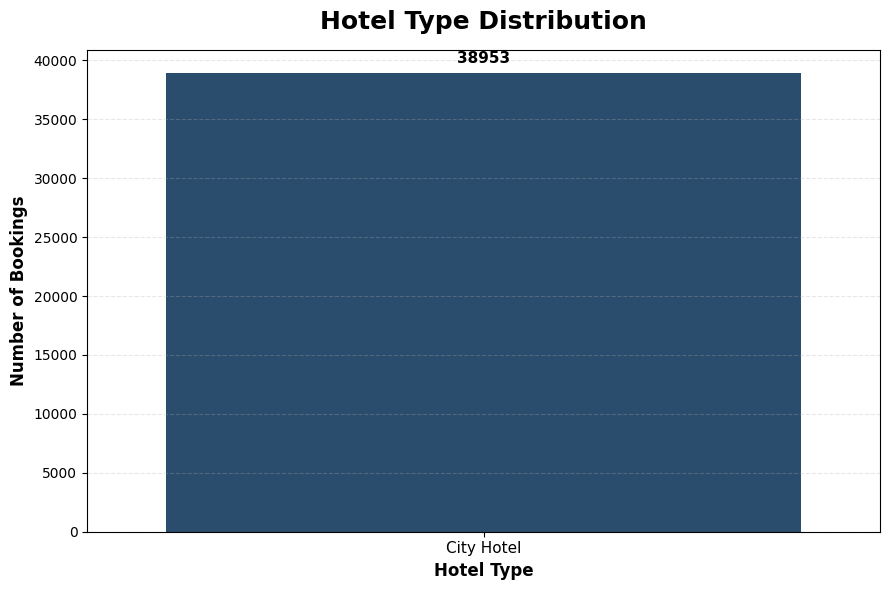

In [ ]:
# Step 4: Hotel Type Distribution

plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="hotel",
    hue="hotel",
    palette=["#1F4E78", "#2A9D8F"],
    legend=False
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Hotel Type Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Hotel Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand booking patterns, cancellation behavior, customer preferences, pricing, and other important trends in the dataset.

### 4.1 Booking Cancellation Analysis

The distribution of canceled and non-canceled bookings was analyzed to understand the overall cancellation behavior of hotel bookings.

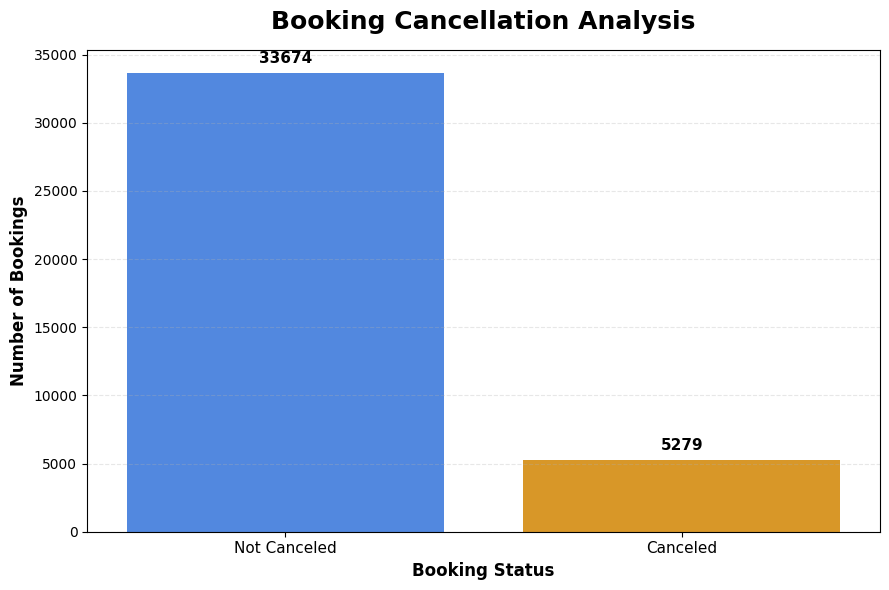

In [ ]:
# Step 5: ## 4. Exploratory Data Analysis (EDA)

plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="is_canceled",
    hue="is_canceled",
    palette=["#3B82F6", "#F59E0B"],
    legend=False
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Booking Cancellation Analysis",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Booking Status",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    [0, 1],
    ["Not Canceled", "Canceled"],
    fontsize=11
)

plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.2 Bookings by Market Segment

The distribution of bookings across different market segments was analyzed to identify the major sources of hotel bookings.

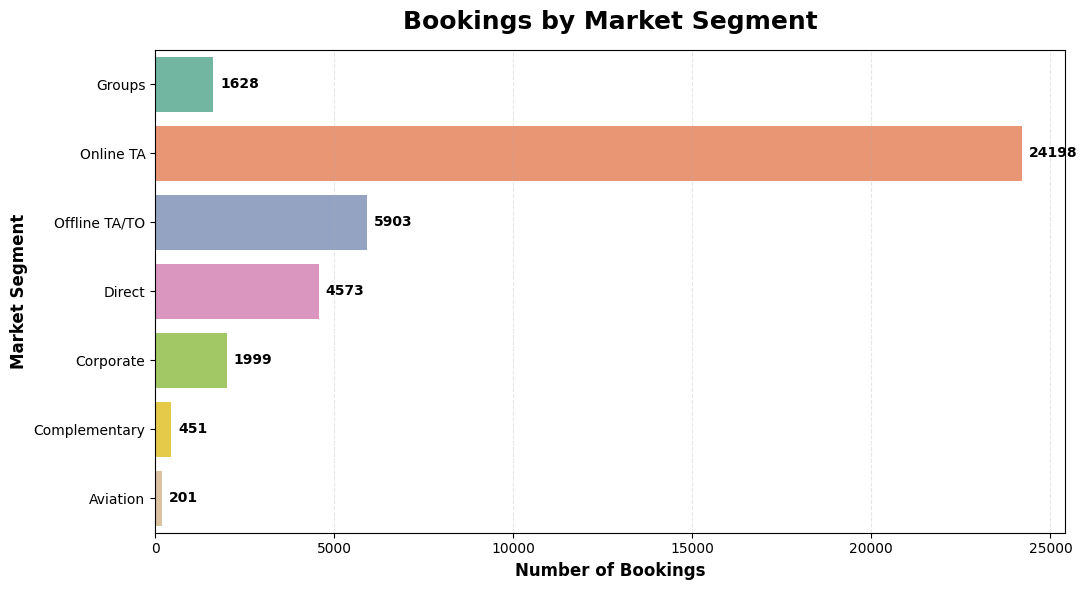

In [ ]:
# Step 6: Bookings by Market Segment

plt.figure(figsize=(11, 6))

ax = sns.countplot(
    data=df,
    y="market_segment",
    hue="market_segment",
    palette="Set2",
    legend=False
)

# Add booking counts
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Bookings by Market Segment",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Market Segment",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.3 Bookings by Customer Type

The distribution of bookings across different customer types was analyzed to understand the composition of the hotel's customer base.

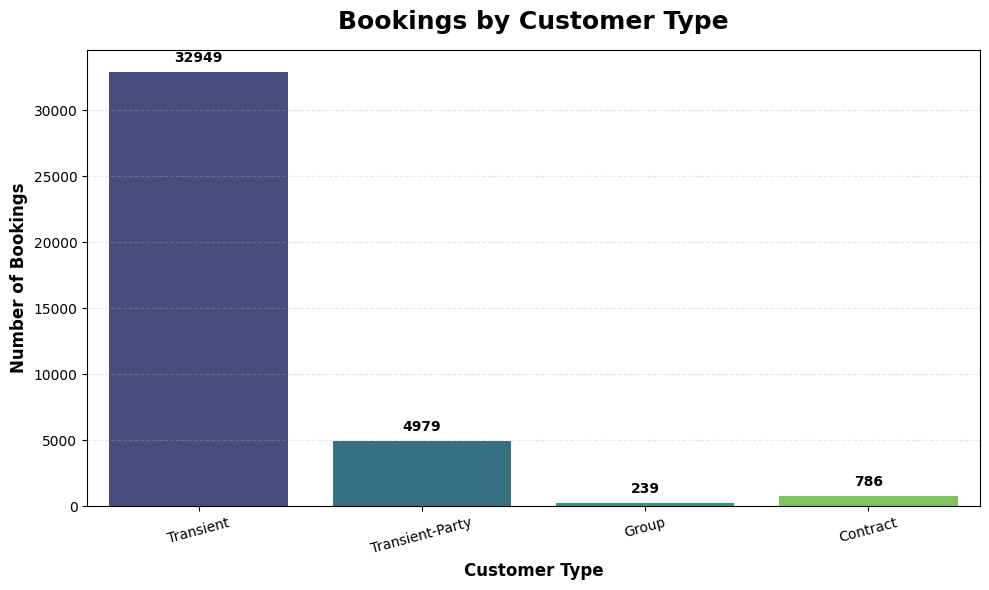

In [ ]:
# Step 7: Bookings by Customer Type

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="customer_type",
    hue="customer_type",
    palette="viridis",
    legend=False
)

# Add booking counts
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Bookings by Customer Type",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Customer Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(rotation=15, fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.4 Average Daily Rate by Hotel Type

The average daily rate (ADR) was compared between different hotel types to understand differences in pricing.

/tmp/ipykernel_926/2439906723.py:7: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  ax = sns.barplot(


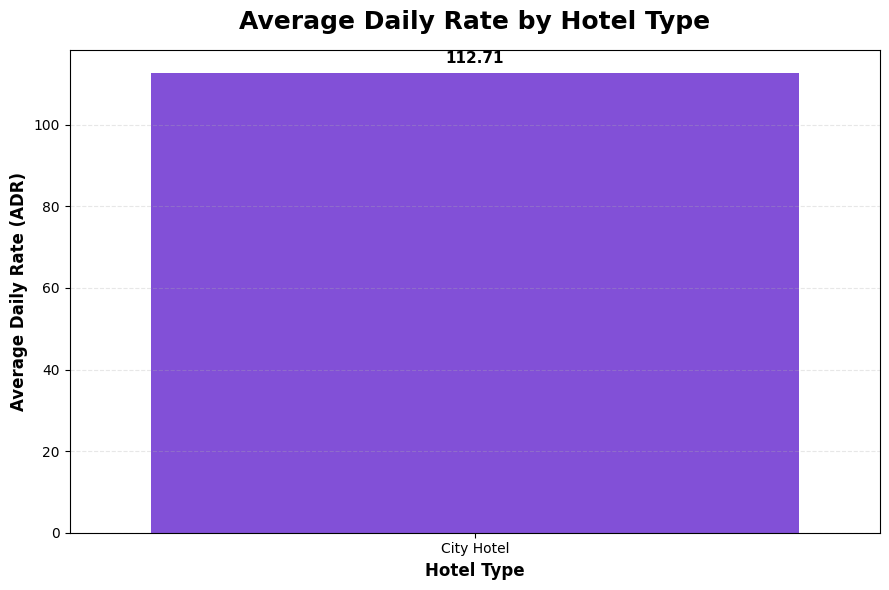

In [ ]:
# Step 8: Average Daily Rate by Hotel Type

adr_by_hotel = df.groupby("hotel")["adr"].mean().reset_index()

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=adr_by_hotel,
    x="hotel",
    y="adr",
    hue="hotel",
    palette=["#7C3AED", "#EC4899"],
    legend=False
)

# Add ADR values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Daily Rate by Hotel Type",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Hotel Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Daily Rate (ADR)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.5 ADR Distribution

The distribution of Average Daily Rate (ADR) was analyzed to understand the pricing pattern and identify the range in which most bookings are concentrated.

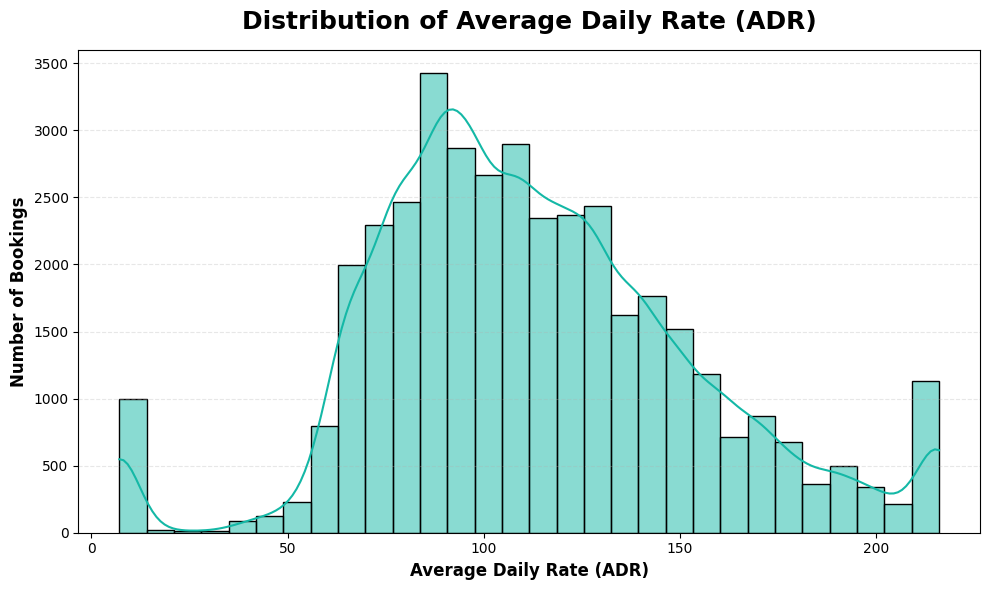

In [ ]:
# Step 9: ADR Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="adr",
    bins=30,
    kde=True,
    color="#14B8A6"
)

plt.title(
    "Distribution of Average Daily Rate (ADR)",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Average Daily Rate (ADR)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.6 Lead Time Distribution

The distribution of booking lead time was analyzed to understand how far in advance guests typically make their reservations.

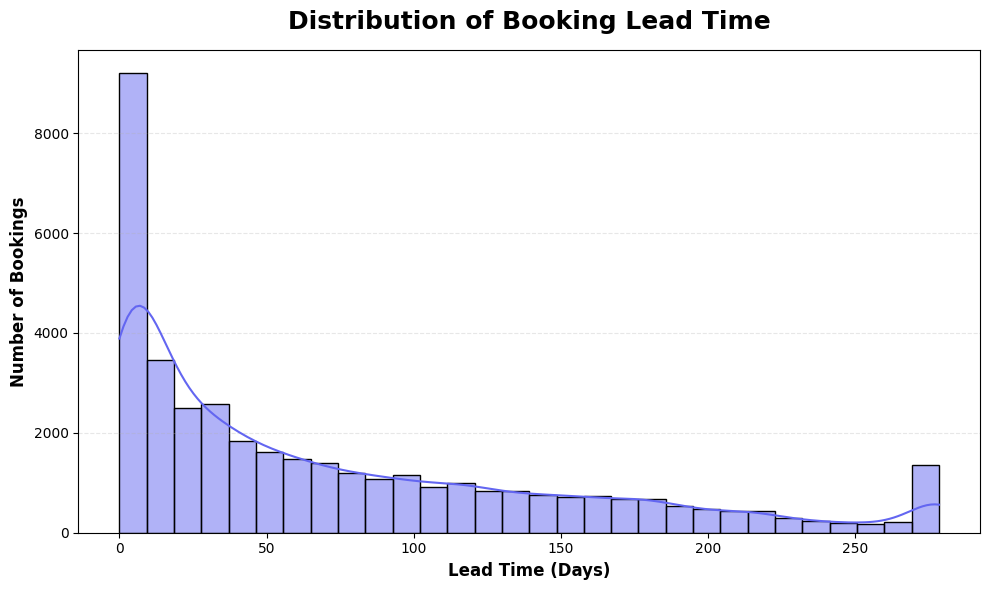

In [ ]:
# Step 10: Lead Time Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="lead_time",
    bins=30,
    kde=True,
    color="#6366F1"
)

plt.title(
    "Distribution of Booking Lead Time",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Lead Time (Days)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.7 Average Stay Duration: Weekend vs Week Nights

The average number of weekend and weekday nights was compared to understand guest stay patterns.

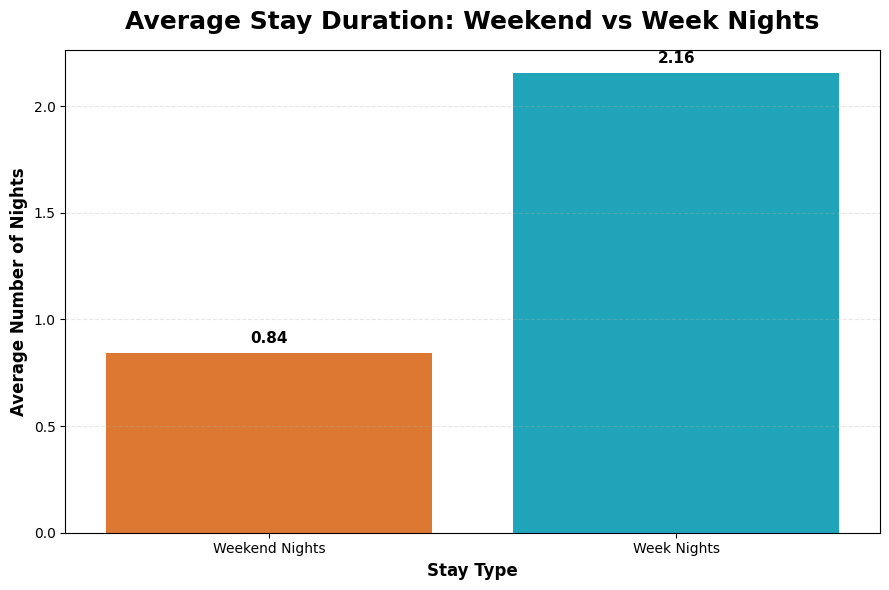

In [ ]:
# Step 11: Stay Duration Analysis

stay_data = pd.DataFrame({
    "Stay Type": ["Weekend Nights", "Week Nights"],
    "Average Nights": [
        df["stays_in_weekend_nights"].mean(),
        df["stays_in_week_nights"].mean()
    ]
})

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=stay_data,
    x="Stay Type",
    y="Average Nights",
    hue="Stay Type",
    palette=["#F97316", "#06B6D4"],
    legend=False
)

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Stay Duration: Weekend vs Week Nights",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Stay Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Number of Nights",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.8 Correlation Analysis

A correlation heatmap was used to examine relationships between numerical variables and identify variables that show stronger or weaker associations with each other.

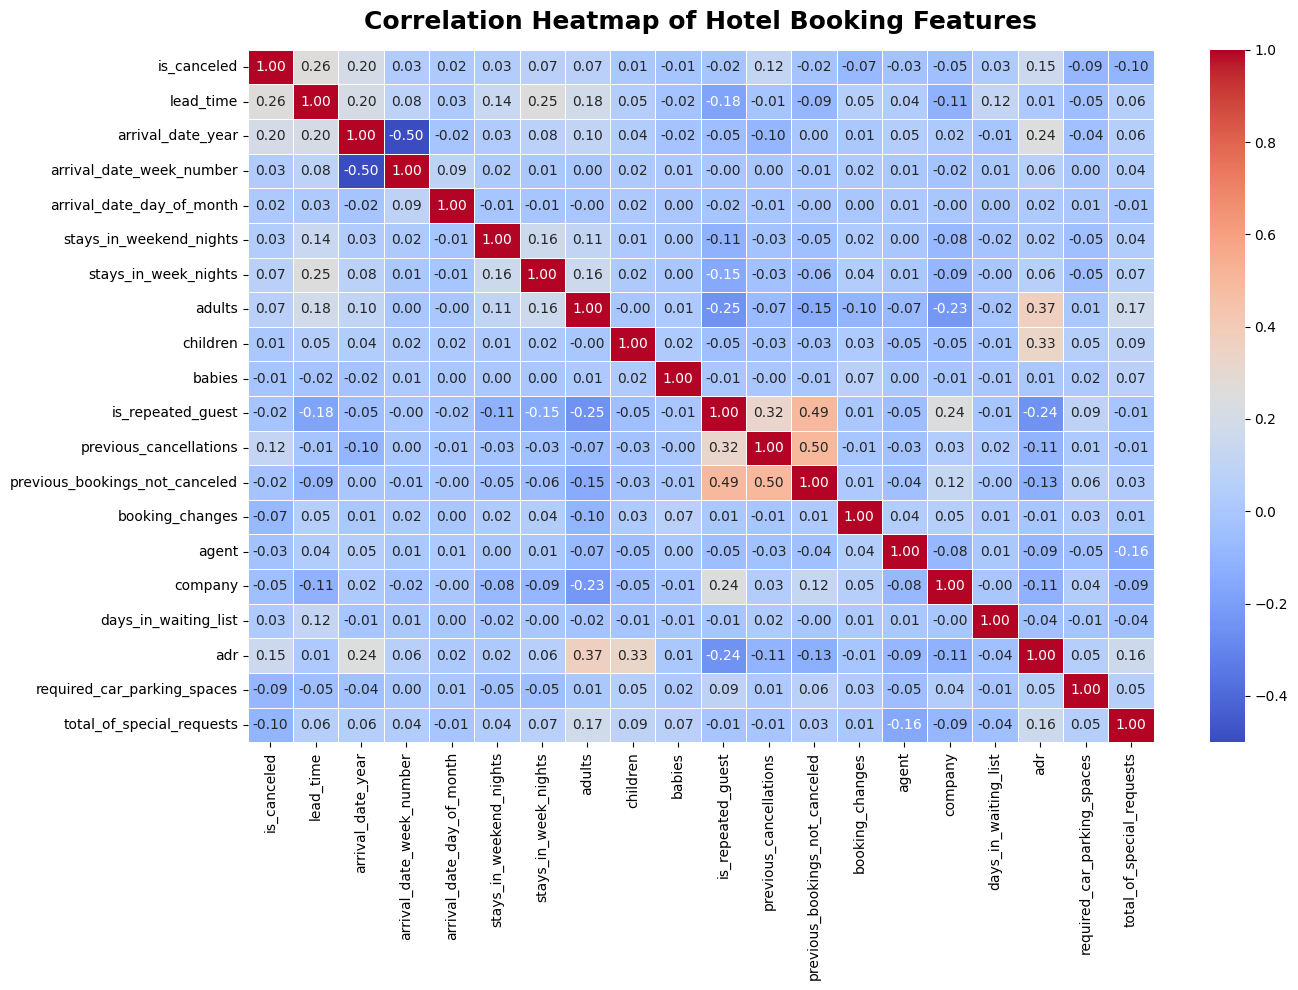

In [ ]:
# Step 12: Correlation Heatmap

plt.figure(figsize=(14, 10))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)

plt.title(
    "Correlation Heatmap of Hotel Booking Features",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

### 4.9 ADR Outlier Analysis

A box plot was used to visualize the spread of Average Daily Rate (ADR) and examine the presence of extreme values after outlier treatment.

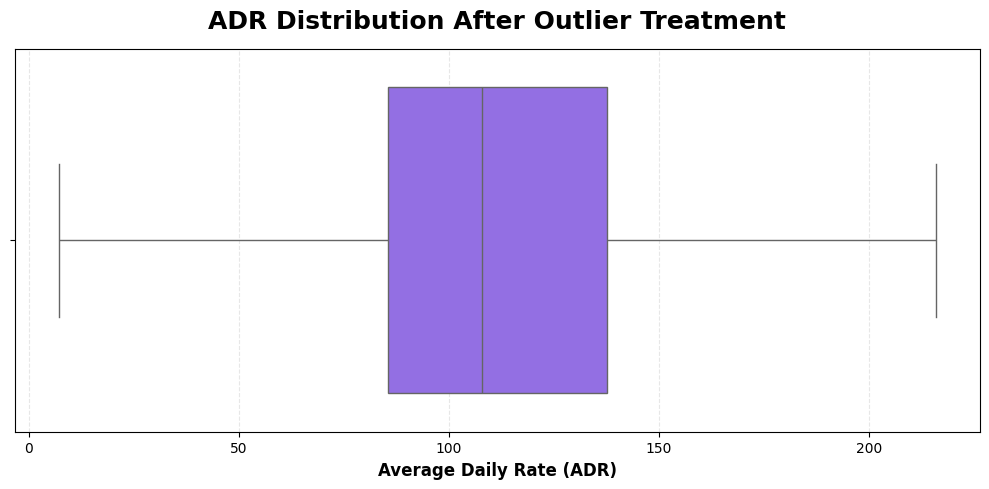

In [ ]:
# Step 13: ADR Box Plot

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["adr"],
    color="#8B5CF6"
)

plt.title(
    "ADR Distribution After Outlier Treatment",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Average Daily Rate (ADR)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.10 Cancellation Rate by Hotel Type

The cancellation rate was compared across hotel types to identify differences in cancellation behavior between properties.

/tmp/ipykernel_926/2318915508.py:12: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  ax = sns.barplot(


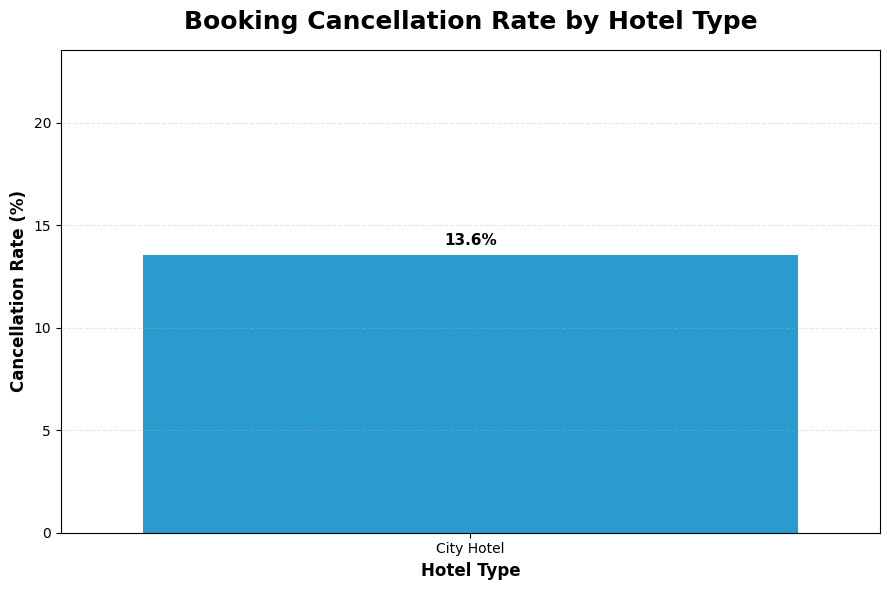

In [ ]:
# Step 14: Cancellation Rate by Hotel Type

cancellation_rate = (
    df.groupby("hotel")["is_canceled"]
      .mean()
      .mul(100)
      .reset_index(name="Cancellation Rate")
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=cancellation_rate,
    x="hotel",
    y="Cancellation Rate",
    hue="hotel",
    palette=["#0EA5E9", "#F43F5E"],
    legend=False
)

# Add percentage values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Booking Cancellation Rate by Hotel Type",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Hotel Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Cancellation Rate (%)",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0, cancellation_rate["Cancellation Rate"].max() + 10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.11 Cancellation Rate by Market Segment

The cancellation rate across different market segments was analyzed to identify variations in booking cancellation behavior among customer groups.

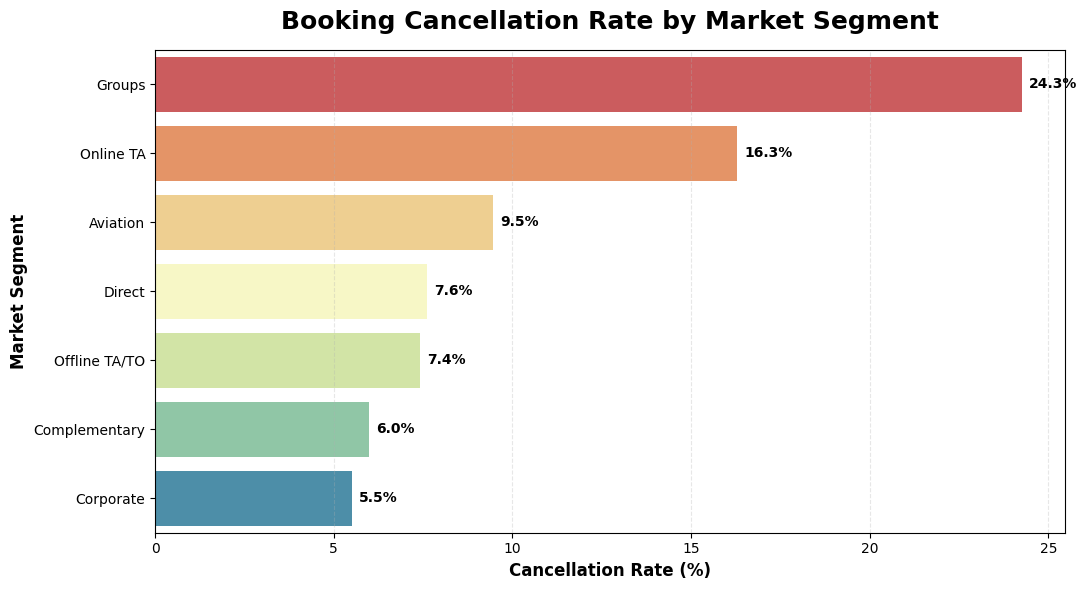

In [ ]:
# Step 15: Cancellation Rate by Market Segment

segment_cancellation = (
    df.groupby("market_segment")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index(name="Cancellation Rate")
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=segment_cancellation,
    x="Cancellation Rate",
    y="market_segment",
    hue="market_segment",
    palette="Spectral",
    legend=False
)

# Add percentage values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Booking Cancellation Rate by Market Segment",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Cancellation Rate (%)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Market Segment",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.12 Monthly Booking Trend

Monthly booking counts were analyzed to identify seasonal patterns and changes in booking demand throughout the year.

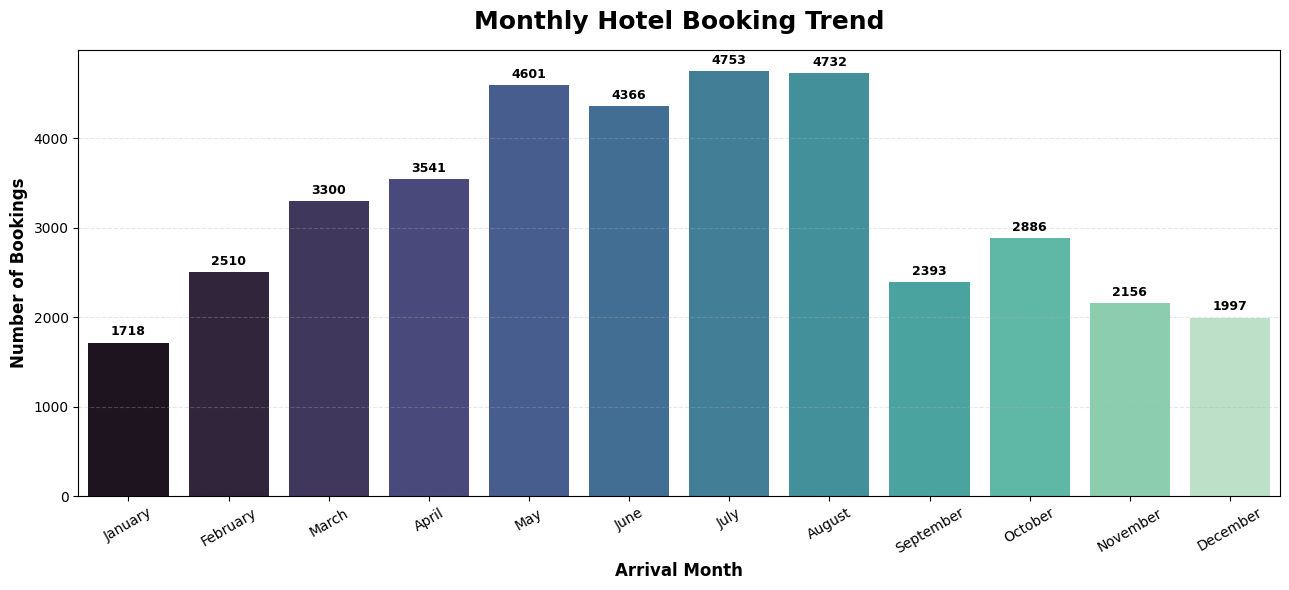

In [ ]:
# Step 16: Monthly Booking Trend

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_bookings = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
    .reset_index()
)

monthly_bookings.columns = ["Month", "Bookings"]

plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=monthly_bookings,
    x="Month",
    y="Bookings",
    hue="Month",
    palette="mako",
    legend=False
)

# Add booking counts
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Monthly Hotel Booking Trend",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Arrival Month",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(rotation=30, fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.13 Booking Changes Analysis

The number of booking changes was analyzed to understand how frequently guests modify their reservations.

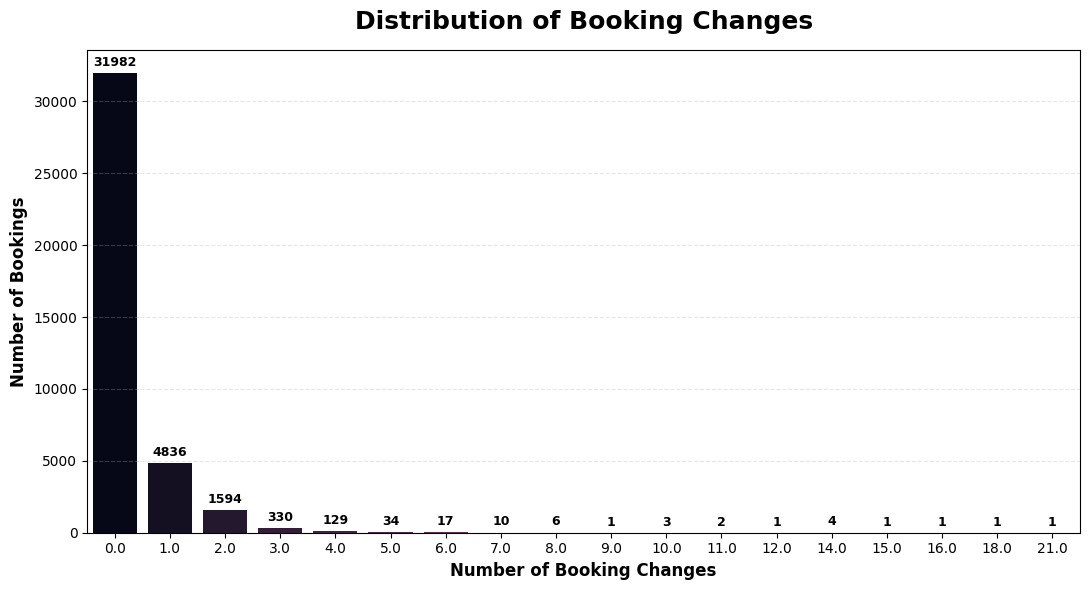

In [ ]:
# Step 17: Booking Changes Analysis

booking_changes = (
    df["booking_changes"]
    .value_counts()
    .sort_index()
    .reset_index()
)

booking_changes.columns = ["Booking Changes", "Number of Bookings"]

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=booking_changes,
    x="Booking Changes",
    y="Number of Bookings",
    hue="Booking Changes",
    palette="rocket",
    legend=False
)

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Distribution of Booking Changes",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Booking Changes",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.14 Special Requests Analysis

The number of special requests made by guests was analyzed to understand guest preferences and service requirements.

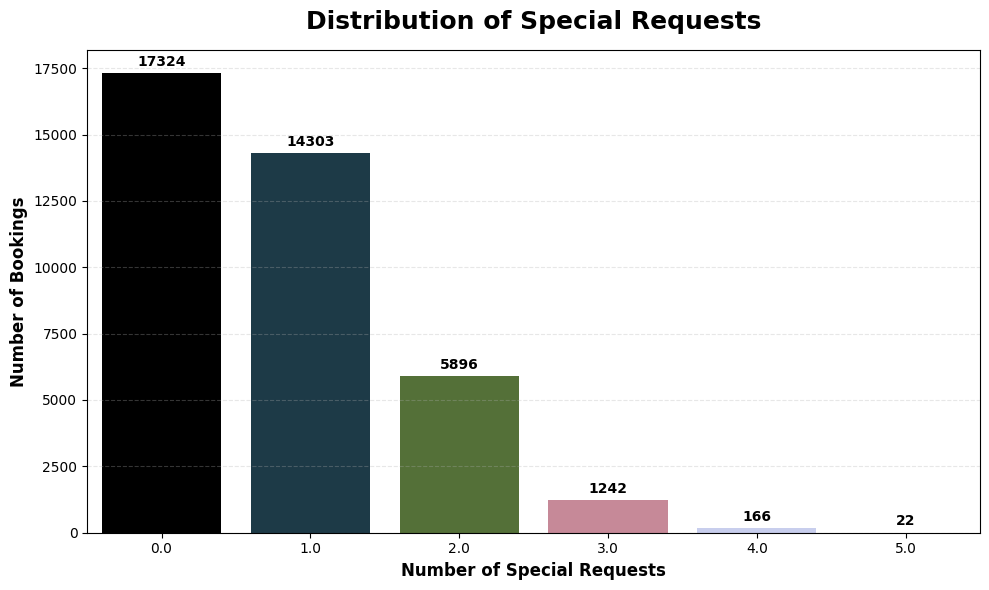

In [ ]:
# Step 18: Special Requests Analysis

special_requests = (
    df["total_of_special_requests"]
    .value_counts()
    .sort_index()
    .reset_index()
)

special_requests.columns = [
    "Special Requests",
    "Number of Bookings"
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=special_requests,
    x="Special Requests",
    y="Number of Bookings",
    hue="Special Requests",
    palette="cubehelix",
    legend=False
)

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Distribution of Special Requests",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Special Requests",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.15 Lead Time Box Plot

A box plot was used to visualize the distribution of booking lead time and identify extreme values after outlier treatment.

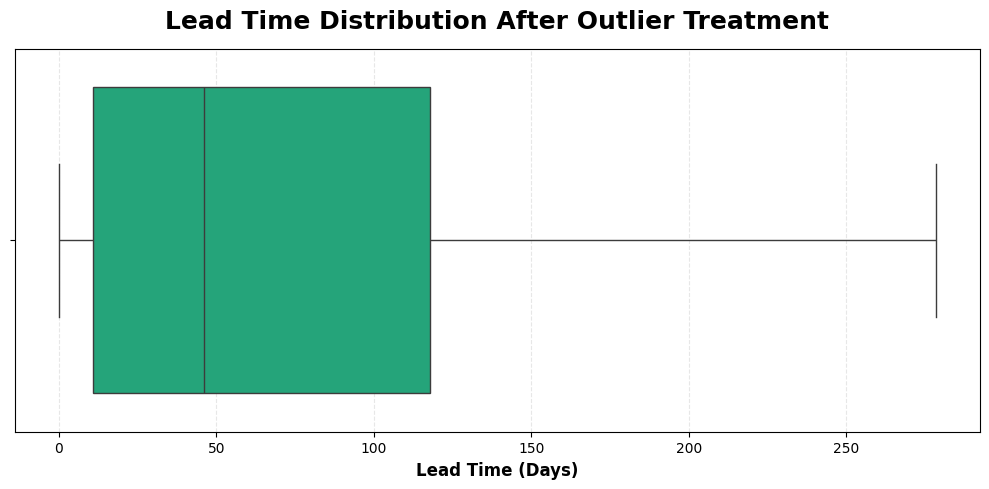

In [ ]:
# Step 19: Lead Time Box Plot

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["lead_time"],
    color="#10B981"
)

plt.title(
    "Lead Time Distribution After Outlier Treatment",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Lead Time (Days)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.16 Weekend vs Weekday Stay Distribution

The distribution of weekend and weekday stays was analyzed to understand how guests divide their stay between weekends and weekdays.

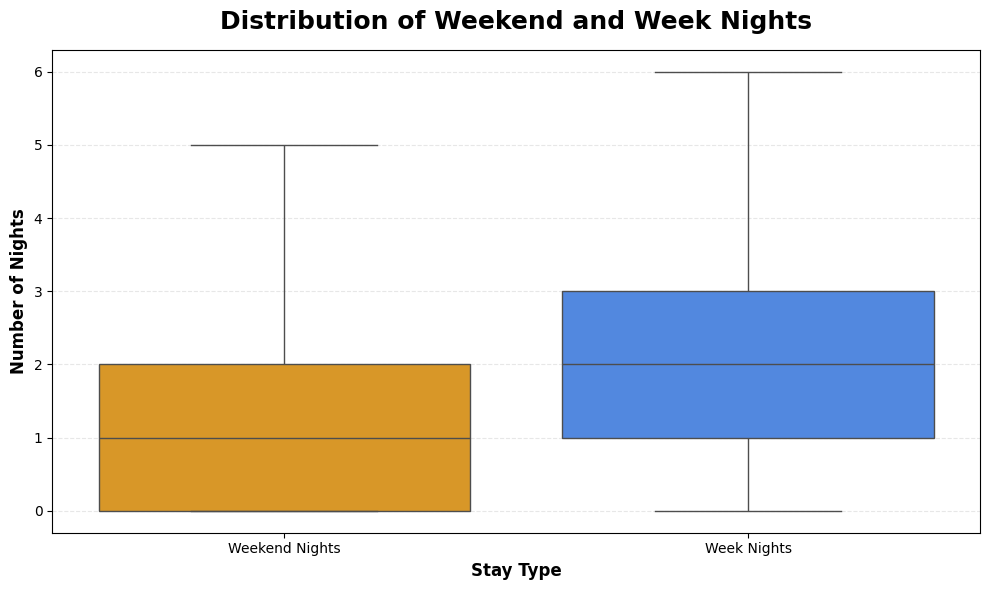

In [ ]:
# Step 20: Stay Nights Distribution

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[
        ["stays_in_weekend_nights", "stays_in_week_nights"]
    ],
    palette=["#F59E0B", "#3B82F6"]
)

plt.title(
    "Distribution of Weekend and Week Nights",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Stay Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Nights",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    [0, 1],
    ["Weekend Nights", "Week Nights"]
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.17 Bookings by Distribution Channel

The distribution of bookings across different distribution channels was analyzed to understand how guests make hotel reservations.

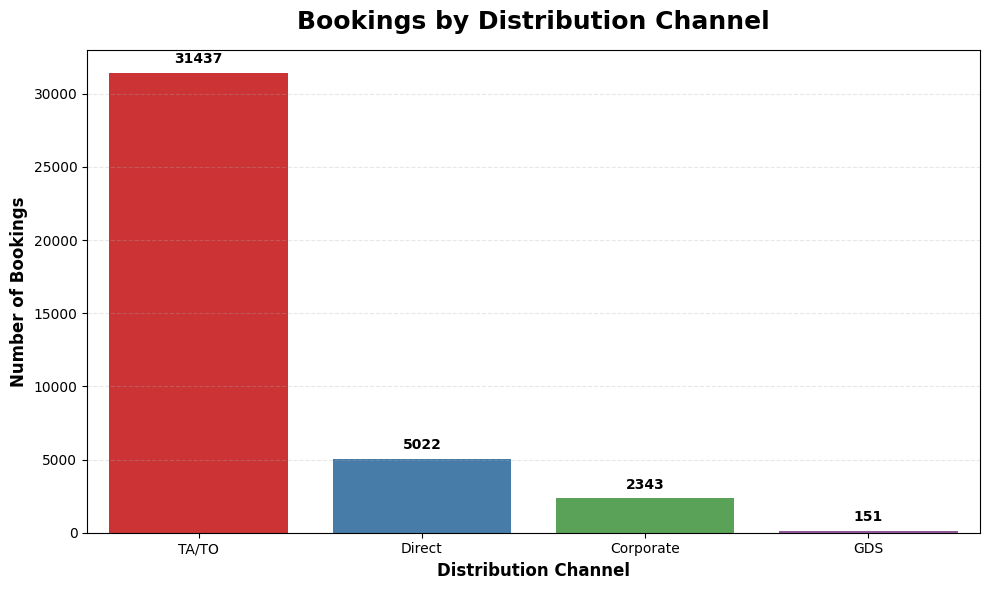

In [ ]:
# Step 21: Bookings by Distribution Channel

channel_bookings = (
    df["distribution_channel"]
    .value_counts()
    .reset_index()
)

channel_bookings.columns = [
    "Distribution Channel",
    "Number of Bookings"
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=channel_bookings,
    x="Distribution Channel",
    y="Number of Bookings",
    hue="Distribution Channel",
    palette="Set1",
    legend=False
)

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Bookings by Distribution Channel",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Distribution Channel",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.18 New vs Repeated Guest Bookings

Bookings from new and repeated guests were compared to understand guest loyalty and the proportion of returning customers.

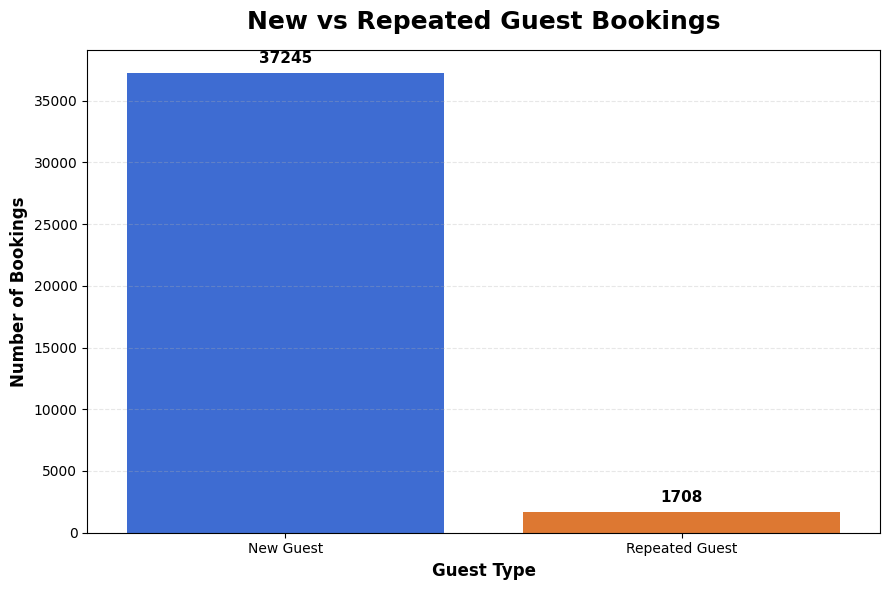

In [ ]:
# Step 22: Repeated Guest Analysis

guest_data = (
    df["is_repeated_guest"]
    .value_counts()
    .sort_index()
    .reset_index()
)

guest_data.columns = [
    "Guest Type",
    "Number of Bookings"
]

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=guest_data,
    x="Guest Type",
    y="Number of Bookings",
    hue="Guest Type",
    palette=["#2563EB", "#F97316"],
    legend=False
)

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "New vs Repeated Guest Bookings",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Guest Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    [0, 1],
    ["New Guest", "Repeated Guest"]
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.19 Guest Meal Preference

Guest meal preferences were analyzed to identify the most commonly selected meal plans among hotel bookings.

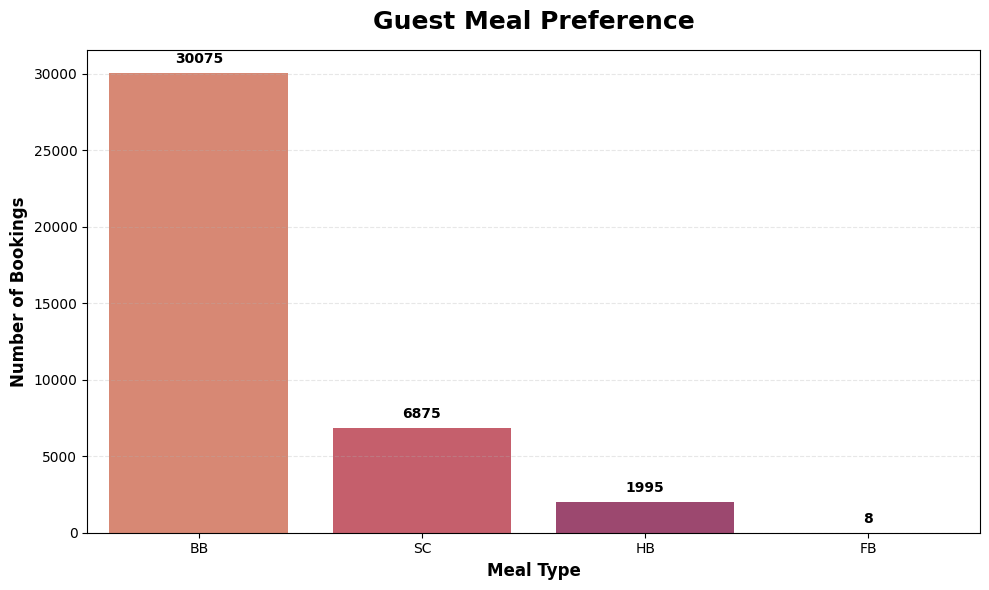

In [ ]:
# Step 23: Meal Preference Analysis

meal_data = (
    df["meal"]
    .value_counts()
    .reset_index()
)

meal_data.columns = [
    "Meal Type",
    "Number of Bookings"
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=meal_data,
    x="Meal Type",
    y="Number of Bookings",
    hue="Meal Type",
    palette="flare",
    legend=False
)

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Guest Meal Preference",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Meal Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.20 Required Car Parking Spaces

The number of car parking spaces requested by guests was analyzed to understand parking requirements and guest preferences.

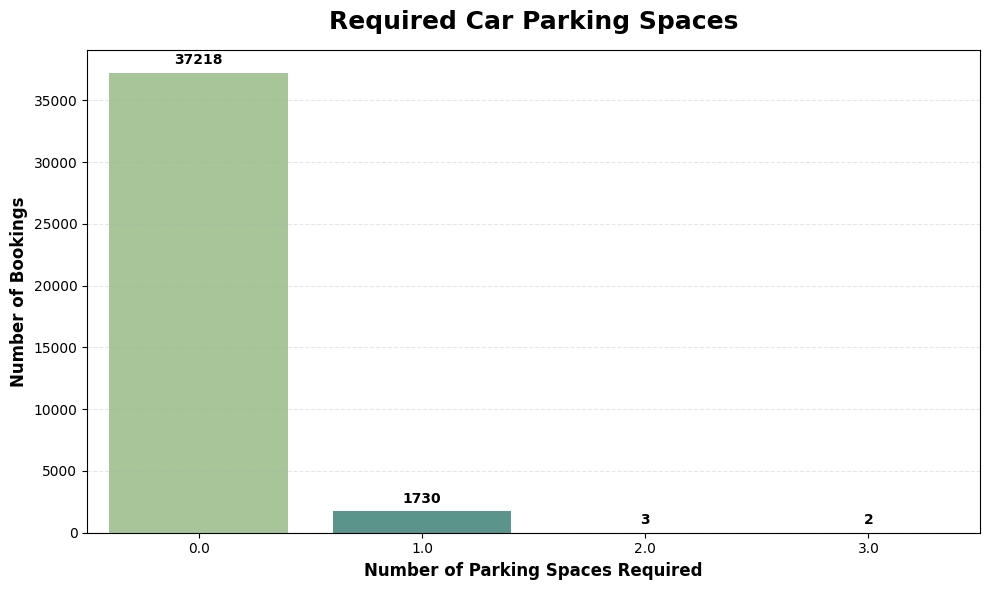

In [ ]:
# Step 24: Parking Space Requirement Analysis

parking_data = (
    df["required_car_parking_spaces"]
    .value_counts()
    .sort_index()
    .reset_index()
)

parking_data.columns = [
    "Parking Spaces Required",
    "Number of Bookings"
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=parking_data,
    x="Parking Spaces Required",
    y="Number of Bookings",
    hue="Parking Spaces Required",
    palette="crest",
    legend=False
)

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Required Car Parking Spaces",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Parking Spaces Required",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 4.21 Arrival Day Analysis

Booking arrivals were analyzed by day of the month to identify patterns and variations in booking activity throughout the month.

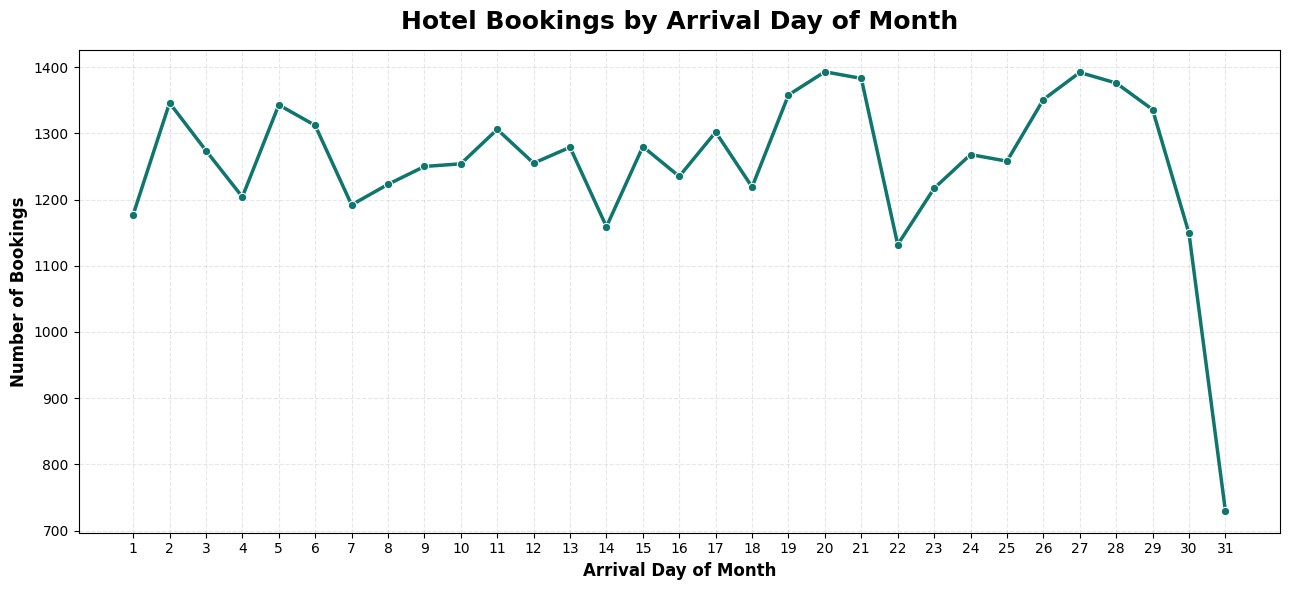

In [ ]:
# Step 25: Arrival Day Analysis

day_data = (
    df["arrival_date_day_of_month"]
    .value_counts()
    .sort_index()
    .reset_index()
)

day_data.columns = [
    "Arrival Day",
    "Number of Bookings"
]

plt.figure(figsize=(13, 6))

ax = sns.lineplot(
    data=day_data,
    x="Arrival Day",
    y="Number of Bookings",
    marker="o",
    linewidth=2.5,
    color="#0F766E"
)

plt.title(
    "Hotel Bookings by Arrival Day of Month",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Arrival Day of Month",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Bookings",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(range(1, 32))

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 5. Key Insights

The analysis revealed several important patterns in hotel booking behavior:

- **City Hotel** received the highest number of bookings.
- The overall booking cancellation rate was approximately **13.55%**.
- **Groups** had the highest cancellation rate among the analyzed market segments.
- **BB (Bed & Breakfast)** was the most commonly selected meal type.
- **Transient** was the most common customer type.
- The average **ADR (Average Daily Rate)** was approximately **112.71**.
- The average booking **lead time** was approximately **74 days**.
- The average total stay duration was approximately **3 nights**.

These findings provide useful insights into customer behavior, booking patterns, pricing, and cancellation trends.

In [ ]:
# Step 26: Generate Key Insights

print("===== KEY INSIGHTS =====\n")

# 1. Hotel with most bookings
hotel_counts = df["hotel"].value_counts()
print("1. Most Booked Hotel:")
print(hotel_counts.idxmax(), "with", hotel_counts.max(), "bookings\n")

# 2. Overall cancellation rate
cancellation_rate = df["is_canceled"].mean() * 100
print("2. Overall Cancellation Rate:")
print(f"{cancellation_rate:.2f}%\n")

# 3. Highest cancellation market segment
segment_rate = (
    df.groupby("market_segment")["is_canceled"]
      .mean()
      .mul(100)
)

print("3. Highest Cancellation Rate Market Segment:")
print(segment_rate.idxmax(), f"({segment_rate.max():.2f}%)\n")

# 4. Most common meal type
meal_counts = df["meal"].value_counts()
print("4. Most Common Meal Type:")
print(meal_counts.idxmax(), "with", meal_counts.max(), "bookings\n")

# 5. Most common customer type
customer_counts = df["customer_type"].value_counts()
print("5. Most Common Customer Type:")
print(customer_counts.idxmax(), "with", customer_counts.max(), "bookings\n")

# 6. Average ADR
print("6. Average ADR:")
print(f"{df['adr'].mean():.2f}\n")

# 7. Average lead time
print("7. Average Booking Lead Time:")
print(f"{df['lead_time'].mean():.2f} days\n")

# 8. Average stay duration
avg_stay = (
    df["stays_in_weekend_nights"].mean()
    + df["stays_in_week_nights"].mean()
)

print("8. Average Total Stay Duration:")
print(f"{avg_stay:.2f} nights")

===== KEY INSIGHTS =====

1. Most Booked Hotel:
City Hotel with 38953 bookings

2. Overall Cancellation Rate:
13.55%

3. Highest Cancellation Rate Market Segment:
Groups (24.26%)

4. Most Common Meal Type:
BB with 30075 bookings

5. Most Common Customer Type:
Transient with 32949 bookings

6. Average ADR:
112.71

7. Average Booking Lead Time:
74.21 days

8. Average Total Stay Duration:
3.00 nights


## 6. Export Cleaned Dataset

The cleaned dataset was exported as a CSV file for future analysis and reuse. The final dataset contains **38,953 records and 32 columns** after data cleaning and preprocessing.

In [ ]:
# Step 27: Export Cleaned Dataset

output_file = "cleaned_hotel_booking.csv"

df.to_csv(output_file, index=False)

print("Cleaned dataset exported successfully!")
print("File:", output_file)
print("Shape:", df.shape)

Cleaned dataset exported successfully!
File: cleaned_hotel_booking.csv
Shape: (38953, 32)
